In [1]:
!pip install mlflow tensorflow scikit-learn pandas numpy matplotlib seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 84.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 68.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 838.5/838.5 kB 29.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20

In [2]:
# Bibliotēku imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer

# Datu ielāde
iris = load_iris()

# Pārvēršam par tabulu
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = iris.target_names[iris.target]

# Datu izpēte
print("Datu forma:", df.shape)
print("\nPirmās 5 rindas:")
print(df.head())
print("\nDatu tipi:")
print(df.dtypes)
print("\nTrūkstošās vērtības:")
print(df.isnull().sum())

Datu forma: (150, 5)

Pirmās 5 rindas:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

Datu tipi:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species               object
dtype: object

Trūkstošās vērtības:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64


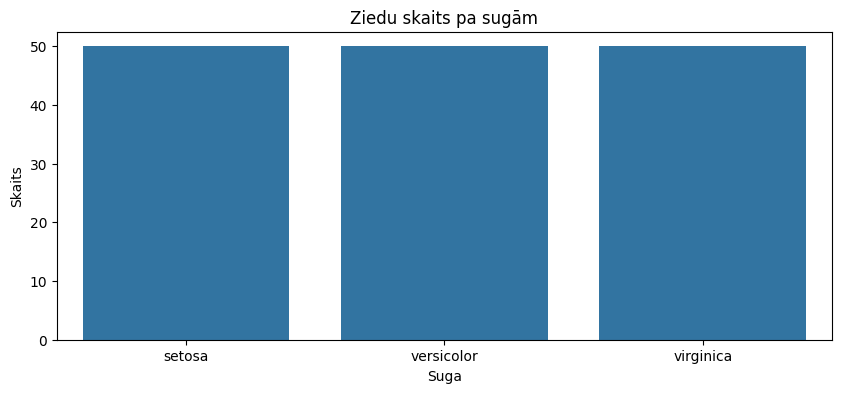

Apmācības dati: (105, 4)
Validācijas dati: (22, 4)
Testēšanas dati: (23, 4)


In [3]:
# Vizualizācija - paskatāmies uz datiem
plt.figure(figsize=(10, 4))
sns.countplot(x='species', data=df)
plt.title("Ziedu skaits pa sugām")
plt.xlabel("Suga")
plt.ylabel("Skaits")
plt.show()

# Datu sagatavošana modelim
# Atdalām iezīmes no atbildēm
X = df.drop('species', axis=1).values  # 4 mērījumi
y = df['species'].values                # sugas nosaukumi

# Kodējam sugas kā skaitļus (setosa=0, versicolor=1, virginica=2)
lb = LabelBinarizer()
y_encoded = lb.fit_transform(y)  # pārvērš par [1,0,0], [0,1,0], [0,0,1]

# Normalizācija - pārvēršam visus skaitļus vienā mērogā
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Sadalām datos: 70% apmācībai, 15% validācijai, 15% testēšanai
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Apmācības dati:", X_train.shape)
print("Validācijas dati:", X_val.shape)
print("Testēšanas dati:", X_test.shape)

In [4]:
# Keras bibliotēku imports
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

# Modeļa izveide
model = keras.Sequential([
    # Pirmais slānis - 64 neironi
    layers.Dense(64, activation='relu', input_shape=(4,)),
    # Dropout - izslēdz 30% neironu nejauši, lai novērstu pārmācīšanos
    layers.Dropout(0.3),
    # Otrais slānis - 32 neironi
    layers.Dense(32, activation='relu'),
    # Dropout
    layers.Dropout(0.3),
    # Izvades slānis - 3 neironi (viens katrai sugai)
    layers.Dense(3, activation='softmax')
])

# Modeļa kompilēšana
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Modeļa struktūras izdruka
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,499 (9.76 KB)

 Trainable params: 2,499 (9.76 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
# Apstājamies ja modelis vairs neuzlabojas
early_stop = EarlyStopping(
    monitor='val_loss',   # sekojam validācijas kļūdai
    patience=10,          # gaidām 10 epohās pirms apstāties
    restore_best_weights=True  # atjaunojam labākos svarus
)

# Modeļa trenēšana
history = model.fit(
    X_train, y_train,
    epochs=100,                    # maksimāli 100 epohās
    batch_size=16,                 # 16 ziedi vienā solī
    validation_data=(X_val, y_val), # validācijas dati
    callbacks=[early_stop],        # agrīnā apstāšanās
    verbose=1                      # rādam progresu
)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 54ms/step - accuracy: 0.5429 - loss: 0.9706 - val_accuracy: 0.9091 - val_loss: 0.7940
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6476 - loss: 0.8975 - val_accuracy: 0.9091 - val_loss: 0.6967
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7524 - loss: 0.8349 - val_accuracy: 0.9545 - val_loss: 0.6076
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7524 - loss: 0.7364 - val_accuracy: 0.9545 - val_loss: 0.5305
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7429 - loss: 0.7254 - val_accuracy: 0.9545 - val_loss: 0.4612
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8476 - loss: 0.6309 - val_accuracy: 0.9545 - val_loss: 0.4027
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8190 - loss: 0.6043 - val_accuracy: 0.9545 - val_loss: 0.3542
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8000 - loss: 0.5539 - val_accuracy: 0.9545 - val_loss:

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
Klasifikācijas atskaite:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00         6
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00         7

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



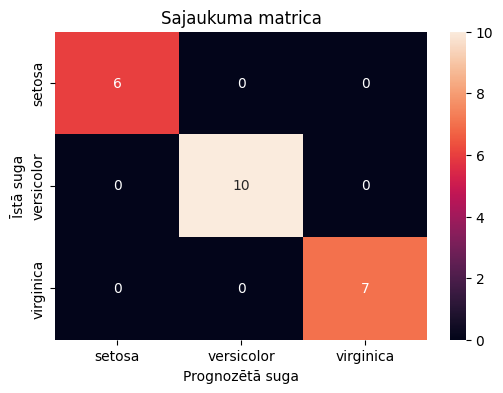

In [6]:
# Metrikas aprēķināšana
from sklearn.metrics import classification_report, confusion_matrix

# Prognozes uz testēšanas datiem
y_pred_proba = model.predict(X_test)           # varbūtības
y_pred = np.argmax(y_pred_proba, axis=1)       # izvēlamies lielāko
y_true = np.argmax(y_test, axis=1)             # īstās atbildes

# Metriku izvade
print("Klasifikācijas atskaite:")
print(classification_report(y_true, y_pred, target_names=lb.classes_))

# Sajaukuma matrica
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=lb.classes_,
            yticklabels=lb.classes_)
plt.title("Sajaukuma matrica")
plt.ylabel("Īstā suga")
plt.xlabel("Prognozētā suga")
plt.show()

In [7]:
# MLflow bibliotēkas imports
import mlflow
import mlflow.keras

# MLflow eksperimenta nosaukums
mlflow.set_experiment("iris_classification")

print("MLflow versija:", mlflow.__version__)

2026/04/14 08:00:17 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/14 08:00:17 INFO mlflow.store.db.utils: Updating database tables
2026/04/14 08:00:20 INFO mlflow.tracking.fluent: Experiment with name 'iris_classification' does not exist. Creating a new experiment.


MLflow versija: 3.11.1


In [8]:
# Funkcija viena eksperimenta trenēšanai un reģistrēšanai
def train_and_log(experiment_name, units_1, units_2, dropout_rate, epochs, batch_size):

    with mlflow.start_run(run_name=experiment_name):

        # Modeļa izveide ar dotajiem parametriem
        model = keras.Sequential([
            layers.Dense(units_1, activation='relu', input_shape=(4,)),
            layers.Dropout(dropout_rate),
            layers.Dense(units_2, activation='relu'),
            layers.Dropout(dropout_rate),
            layers.Dense(3, activation='softmax')
        ])

        model.compile(
            optimizer='adam',
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        # Trenēšana
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        model.fit(
            X_train, y_train,
            epochs=epochs,
            batch_size=batch_size,
            validation_data=(X_val, y_val),
            callbacks=[early_stop],
            verbose=0  # nedrukājam epohās
        )

        # Metrikas aprēķināšana
        y_pred_proba = model.predict(X_test, verbose=0)
        y_pred = np.argmax(y_pred_proba, axis=1)
        y_true = np.argmax(y_test, axis=1)
        report = classification_report(y_true, y_pred, output_dict=True)

        f1 = report['weighted avg']['f1-score']
        accuracy = report['accuracy']
        precision = report['weighted avg']['precision']
        recall = report['weighted avg']['recall']

        # Parametru reģistrēšana MLflow
        mlflow.log_param("units_1", units_1)
        mlflow.log_param("units_2", units_2)
        mlflow.log_param("dropout_rate", dropout_rate)
        mlflow.log_param("epochs", epochs)
        mlflow.log_param("batch_size", batch_size)

        # Metriku reģistrēšana MLflow
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("accuracy", accuracy)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)

        # Modeļa saglabāšana MLflow
        mlflow.keras.log_model(model, "model")

        print(f"{experiment_name} -> F1: {f1:.4f}, Accuracy: {accuracy:.4f}")

        return model, f1


In [9]:
# 3 eksperimenti ar dažādiem parametriem
results = {}

# 1. eksperiments - mazs modelis
model_1, f1_1 = train_and_log(
    experiment_name="experiment_small",
    units_1=32, units_2=16,
    dropout_rate=0.2,
    epochs=100, batch_size=16
)
results["experiment_small"] = f1_1

# 2. eksperiments - vidējs modelis
model_2, f1_2 = train_and_log(
    experiment_name="experiment_medium",
    units_1=64, units_2=32,
    dropout_rate=0.3,
    epochs=100, batch_size=16
)
results["experiment_medium"] = f1_2

# 3. eksperiments - liels modelis
model_3, f1_3 = train_and_log(
    experiment_name="experiment_large",
    units_1=128, units_2=64,
    dropout_rate=0.4,
    epochs=100, batch_size=8
)
results["experiment_large"] = f1_3

print("\nVisi eksperimenti pabeigti!")
print("Rezultāti:", results)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026/04/14 08:00:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 08:00:35 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


experiment_small -> F1: 1.0000, Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026/04/14 08:01:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 08:01:15 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


experiment_medium -> F1: 1.0000, Accuracy: 1.0000


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026/04/14 08:01:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/14 08:01:47 WARNING mlflow.keras.save: You are saving a Keras model without specifying model signature.


experiment_large -> F1: 1.0000, Accuracy: 1.0000

Visi eksperimenti pabeigti!
Rezultāti: {'experiment_small': 1.0, 'experiment_medium': 1.0, 'experiment_large': 1.0}


In [10]:
# Labākā modeļa izvēle pēc F1 score
best_name = max(results, key=results.get)
print(f"Labākais modelis: {best_name}")
print(f"F1 score: {results[best_name]:.4f}")

# Saglabājam labāko modeli failā
if best_name == "experiment_small":
    best_model = model_1
elif best_name == "experiment_medium":
    best_model = model_2
else:
    best_model = model_3

# Saglabājam kā failu
best_model.save("best_model.keras")
print("Modelis saglabāts: best_model.keras")

Labākais modelis: experiment_small
F1 score: 1.0000
Modelis saglabāts: best_model.keras


In [11]:
# Saglabājam scaler - vajadzīgs lai lietotne apstrādā ievades datus
import joblib

joblib.dump(scaler, "scaler.pkl")
joblib.dump(lb, "label_binarizer.pkl")

print("Scaler saglabāts: scaler.pkl")
print("Label binarizer saglabāts: label_binarizer.pkl")

Scaler saglabāts: scaler.pkl
Label binarizer saglabāts: label_binarizer.pkl


In [12]:
# Pārsaglabājam modeli saderīgā formātā
best_model.save("best_model_v2.keras", save_format="keras")


In [13]:
# Saglabājam H5 formātā - universāli saderīgs
best_model.save("best_model.h5")

In [14]:
runs = mlflow.search_runs(experiment_names=["iris_classification"])
print(runs[['run_id', 'params.units_1', 'params.units_2', 'metrics.f1_score', 'metrics.accuracy']])

                             run_id params.units_1 params.units_2  \
0  733dfb8d460748219a017705879ebfd8            128             64   
1  183c202bb83145a8b17b592de5e00eae             64             32   
2  67fddcfb2f044e7586fc366b442b95c9             32             16   

   metrics.f1_score  metrics.accuracy  
0               1.0               1.0  
1               1.0               1.0  
2               1.0               1.0  


In [17]:
# Parādām eksperimentus kā tabulu
import mlflow
import pandas as pd

runs = mlflow.search_runs(experiment_names=["iris_classification"])
display(runs[['tags.mlflow.runName', 'params.units_1', 'params.units_2',
              'params.dropout_rate', 'metrics.f1_score', 'metrics.accuracy']])

,tags.mlflow.runName,params.units_1,params.units_2,params.dropout_rate,metrics.f1_score,metrics.accuracy
0,experiment_large,128,64,0.4,1.0,1.0
1,experiment_medium,64,32,0.3,1.0,1.0
2,experiment_small,32,16,0.2,1.0,1.0


In [18]:
# Saglabājam train.py failu
train_code = '''
import pandas as pd
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report
import mlflow
import mlflow.keras
import joblib

# Datu ielāde
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target_names[iris.target]

# Datu sagatavošana
X = df.drop("species", axis=1).values
y = df["species"].values

lb = LabelBinarizer()
y_encoded = lb.fit_transform(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_encoded, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# MLflow eksperimenti
mlflow.set_experiment("iris_classification")

def train_and_log(name, units_1, units_2, dropout_rate, epochs, batch_size):
    with mlflow.start_run(run_name=name):
        model = keras.Sequential([
            keras.Input(shape=(4,)),
            layers.Dense(units_1, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(units_2, activation="relu"),
            layers.Dropout(dropout_rate),
            layers.Dense(3, activation="softmax")
        ])
        model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

        early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)
        model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size,
                  validation_data=(X_val, y_val), callbacks=[early_stop], verbose=0)

        y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
        y_true = np.argmax(y_test, axis=1)
        report = classification_report(y_true, y_pred, output_dict=True)

        f1 = report["weighted avg"]["f1-score"]
        mlflow.log_params({"units_1": units_1, "units_2": units_2, "dropout_rate": dropout_rate})
        mlflow.log_metrics({"f1_score": f1, "accuracy": report["accuracy"]})
        mlflow.keras.log_model(model, "model")

        return model, f1

results = {}
model_1, f1_1 = train_and_log("experiment_small", 32, 16, 0.2, 100, 16)
results["experiment_small"] = (model_1, f1_1)
model_2, f1_2 = train_and_log("experiment_medium", 64, 32, 0.3, 100, 16)
results["experiment_medium"] = (model_2, f1_2)
model_3, f1_3 = train_and_log("experiment_large", 128, 64, 0.4, 100, 16)
results["experiment_large"] = (model_3, f1_3)

# Labākā modeļa saglabāšana
best_name = max(results, key=lambda k: results[k][1])
best_model = results[best_name][0]
best_model.save("best_model.h5")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(lb, "label_binarizer.pkl")

print(f"Labākais modelis: {best_name}")
print("Faili saglabāti!")
'''

with open("train.py", "w") as f:
    f.write(train_code)

print("train.py izveidots!")

train.py izveidots!
